In [1]:
library(Seurat)
library(reticulate)
library(keras)
library(dplyr)
library(ggalluvial)
library(tidyr)
library(scRepertoire)
library(viridis)
library(scales)
library(RColorBrewer)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘reticulate’ was built under R version 4.4.3”
The keras package is deprecated. Use the keras3 package instead.

Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: ggplot2

Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Loading required package: viridisLite

Warning message:
“package ‘scales’ was built under R version 4.4.3”

Attaching package: ‘scales’


The following object is masked from ‘package:viridis’:

    viridis_pal




In [2]:
so <- readRDS('vst2_clustered_for_activation.rds')

# Clean TCR & Extract top CTaa

In [3]:
library(stringr)

Warning message:
“package ‘stringr’ was built under R version 4.4.3”


In [4]:
meta <- so@meta.data %>%
  mutate(
    TRAV = str_extract(CTgene, "TRAV[^*]*"),
    TRAJ = str_extract(CTgene, "TRAJ[^*]*"),
    TRAC = str_extract(CTgene, "TRAC[^*]*"),
    TRBV = str_extract(CTgene, "TRBV[^*]*"),
    TRBJ = str_extract(CTgene, "TRBJ[^*]*"),
    TRBC = str_extract(CTgene, "TRBC[^*]*")
  )
head(meta)

,orig.ident,nCount_RNA,nFeature_RNA,barcodes,AIFI_PBMC.Flex_L1,AIFI_PBMC.Flex_L2,AIFI_PBMC.Flex_L3,batch_id,cell_name,cell_uuid,⋯,seurat_clusters,pep_enriched,Day_Culture,Day_Culture_pep_enriched,TRAV,TRAJ,TRAC,TRBV,TRBJ,TRBC
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1de16aa05c2011f0a76a2e8167d1be4d,SeuratProject,29867,6645,1de16aa05c2011f0a76a2e8167d1be4d,T cell,Proliferating T cell,Proliferating T cell,EXP-01589-PC,vegetal_sphingine_krill,1de16aa05c2011f0a76a2e8167d1be4d,⋯,13,Non-Activated,Day_4_IL7_IL15,Day_4_IL7_IL15_Non-Activated,TRAV38-1,TRAJ21,TRAC,TRBV28,TRBJ2-7,TRBC2
1de16b545c2011f0a76a2e8167d1be4d,SeuratProject,949,758,1de16b545c2011f0a76a2e8167d1be4d,T cell,Treg,Memory CD4 Treg,EXP-01589-PC,carbonous_improved_xerus,1de16b545c2011f0a76a2e8167d1be4d,⋯,0,Non-Activated,Day_4_IL7_IL15,Day_4_IL7_IL15_Non-Activated,NA,NA,NA,NA,NA,NA
1de16c625c2011f0a76a2e8167d1be4d,SeuratProject,1650,1217,1de16c625c2011f0a76a2e8167d1be4d,T cell,Memory CD4 T cell,CM CD4 T cell,EXP-01589-PC,unrelative_heathenish_koalabear,1de16c625c2011f0a76a2e8167d1be4d,⋯,3,Non-Activated,Day_4_IL7_IL15,Day_4_IL7_IL15_Non-Activated,TRAV4,TRAJ3,TRAC,TRBV3-1,TRBJ2-5,TRBC2
1de16d5c5c2011f0a76a2e8167d1be4d,SeuratProject,1831,1279,1de16d5c5c2011f0a76a2e8167d1be4d,T cell,Memory CD8 T cell,ISG+ memory CD4 T cell,EXP-01589-PC,cold_greenish_chrysalis,1de16d5c5c2011f0a76a2e8167d1be4d,⋯,3,Non-Activated,Day_4_IL7_IL15,Day_4_IL7_IL15_Non-Activated,NA,NA,NA,TRBV24-1,TRBJ2-2,TRBC2
1de16dde5c2011f0a76a2e8167d1be4d,SeuratProject,1651,1146,1de16dde5c2011f0a76a2e8167d1be4d,T cell,Naive CD4 T cell,ISG+ naive CD4 T cell,EXP-01589-PC,landpoor_loving_wallaroo,1de16dde5c2011f0a76a2e8167d1be4d,⋯,0,Non-Activated,Day_4_IL7_IL15,Day_4_IL7_IL15_Non-Activated,TRAV26-1,TRAJ49,TRAC,TRBV3-1,TRBJ2-3,TRBC2
1de16e565c2011f0a76a2e8167d1be4d,SeuratProject,3839,2306,1de16e565c2011f0a76a2e8167d1be4d,T cell,gdT,Adaptive NK cell,EXP-01589-PC,censorable_detestable_fox,1de16e565c2011f0a76a2e8167d1be4d,⋯,4,Non-Activated,Day_4_IL7_IL15,Day_4_IL7_IL15_Non-Activated,NA,NA,NA,NA,NA,NA


In [5]:
so$CTgene_archive <- so$CTgene

In [6]:
so$CTgene <- paste0(meta$TRAV,'.',meta$TRAJ,'.',meta$TRAC,'_',meta$TRBV,'.',meta$TRBJ,'.',meta$TRBC)

In [7]:
so$CTaa_TRA <- stringr::str_split_i(string = so$CTaa, pattern = '_', i = 1)
so$CTaa_TRB <- stringr::str_split_i(string = so$CTaa, pattern = '_', i = 2)

In [8]:
so$CDR3a <- stringr::str_split_i(string = so$CTaa_TRA, pattern = ';', i = 1)
so$CTaa_TRA_2 <- stringr::str_split_i(string = so$CTaa_TRA, pattern = ';', i = 2)
so$CDR3b <- stringr::str_split_i(string = so$CTaa_TRB, pattern = ';', i = 1)
so$CTaa_TRB_2 <- stringr::str_split_i(string = so$CTaa_TRB, pattern = ';', i = 2)

In [9]:
so$CTaa_archive <- so$CTaa

In [10]:
so$CTaa <- paste(so$CDR3a,so$CDR3b,sep='_')

In [11]:
top_20_CTaa <- as.data.frame(sort(table(so$CTaa),decreasing = T))$Var1[2:21]
top_20_CTaa <- droplevels(top_20_CTaa)
top_20_CTaa <- as.character(top_20_CTaa)
top_20_CTaa

[1] "CAGKTSYDKVIF_CASSPGDEQFF"           "CAMRDHV_NDYKLSF"                   
 [3] "CADETGGGNKLTF_CSARDVVQGDFRIGYTF"    "CALSAPA_GNEKLTF"                   
 [5] "CAVKAAGNKLTF_CASMGDTIYF"            "CAASADNAGNMLTF_CASSLPSALEQFF"      
 [7] "CALRGMNRDDKIIF_CASSISAQPQHF"        "CADETGGGNKLTF_AGSYQLTF"            
 [9] "CAGKTSYDKVIF_NA"                    "CADETGGGNKLTF_NA"                  
[11] "NA_CASSPGDEQFF"                     "CAVRAAGNKLTF_CASMGDTQYF"           
[13] "CAVKAAGNKLTF_NA"                    "CAFMFFGGSNYKLTF_CAWSGGGRYTGELFF"   
[15] "CAMWTGFQKLVF_CASSMGTGGEAFF"         "CGTEDHNNNDMRF_CASSESRYSEAFF"       
[17] "NA_CASMGDTIYF"                      "CAGVGSTSGTYKYIF_CASSEANLLAVYNNEQFF"
[19] "CVVVDWGNTPLVF_CASRPSLALQETQYF"      "CAASADNAGNMLTF_CARDPPGLHYNEQFF"

# Alluvial plots via scRepertoire

In [12]:
so$Culture[is.na(so$Culture)] <- 'NA'
so$Peptide[is.na(so$Peptide)] <- 'NA'

In [13]:
color_table <- data.frame(CTaa = sort(top_20_CTaa),
                          colors = hue_pal()(20))
color_table

CTaa,colors
<chr>,<chr>
CAASADNAGNMLTF_CARDPPGLHYNEQFF,#F8766D
CAASADNAGNMLTF_CASSLPSALEQFF,#EA8331
CADETGGGNKLTF_AGSYQLTF,#D89000
CADETGGGNKLTF_CSARDVVQGDFRIGYTF,#C09B00
CADETGGGNKLTF_NA,#A3A500
CAFMFFGGSNYKLTF_CAWSGGGRYTGELFF,#7CAE00
CAGKTSYDKVIF_CASSPGDEQFF,#39B600
CAGKTSYDKVIF_NA,#00BB4E
CAGVGSTSGTYKYIF_CASSEANLLAVYNNEQFF,#00BF7D


Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


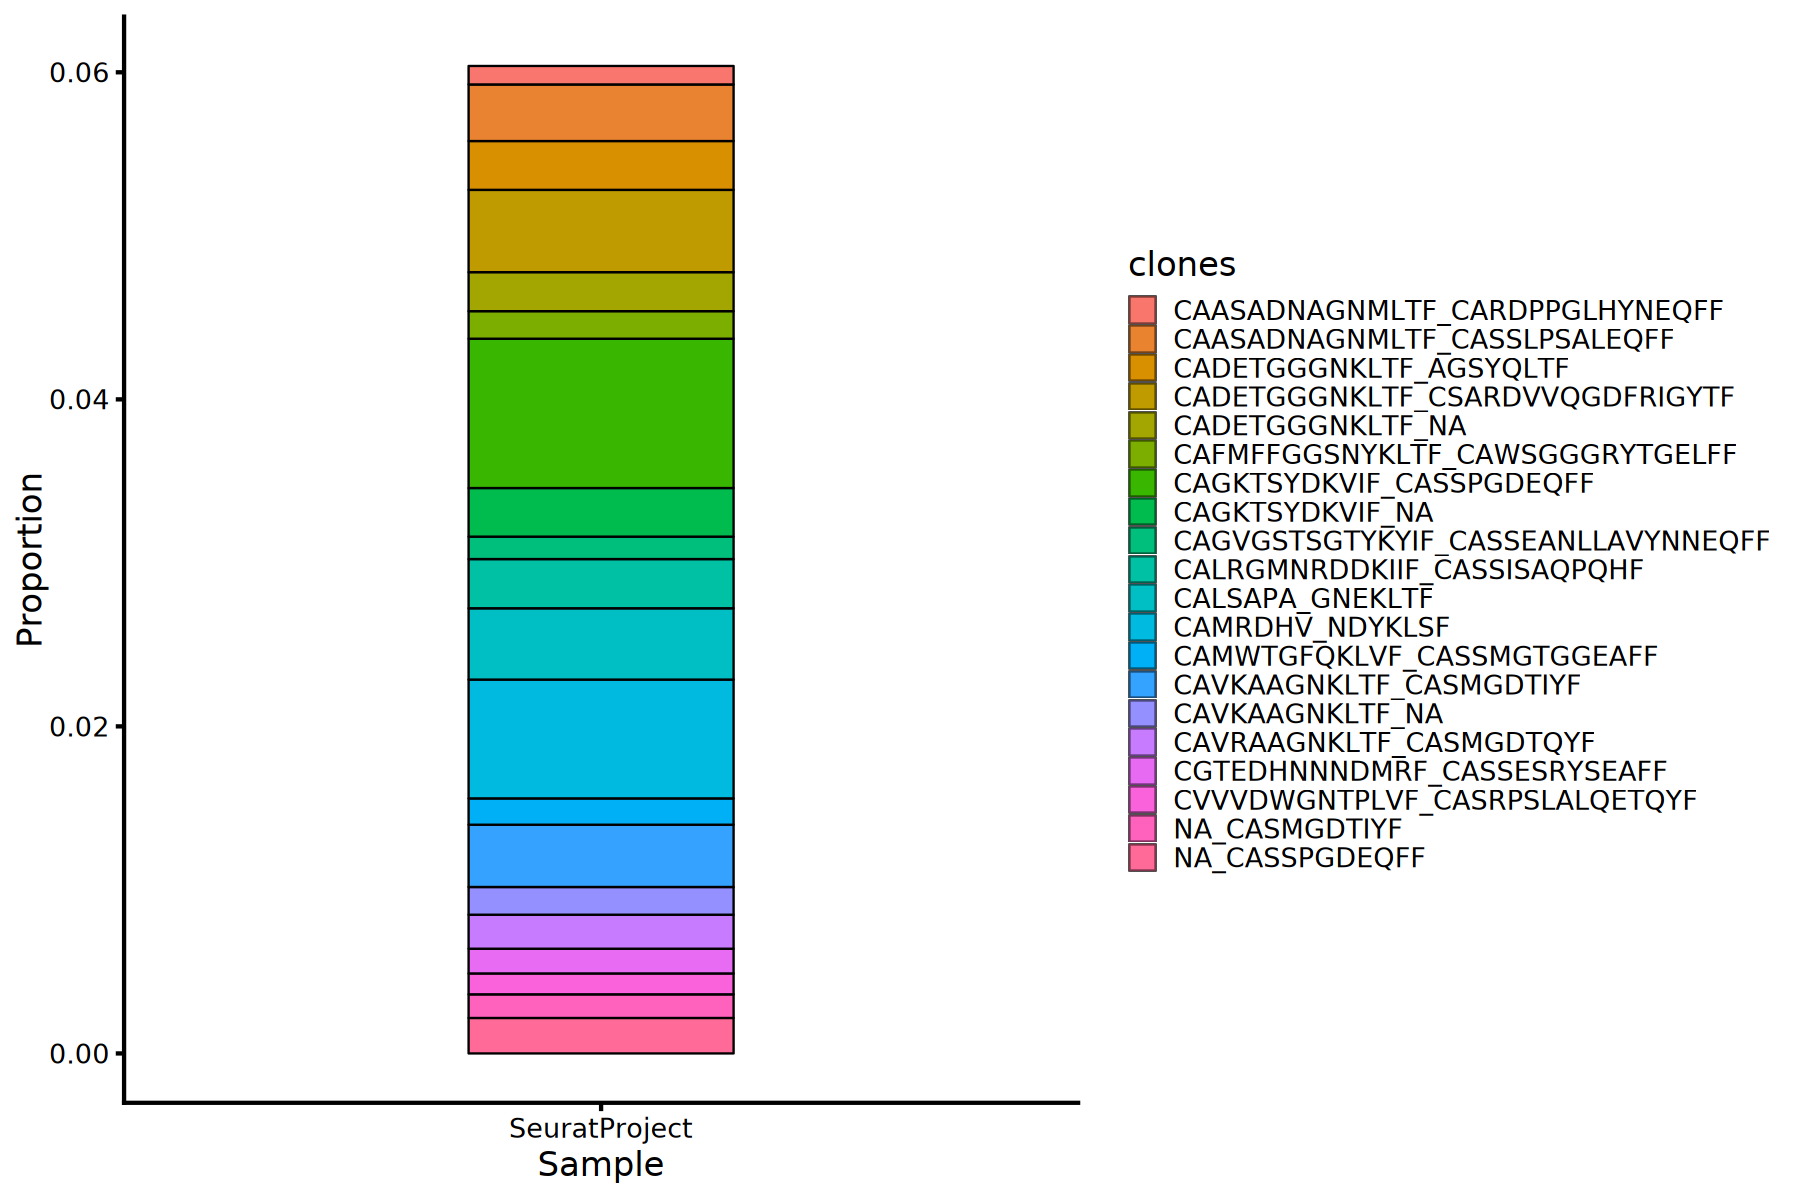

In [14]:
options(repr.plot.width = 15, repr.plot.height = 10)
p1 <- clonalCompare(so, clones = top_20_CTaa, cloneCall="aa", graph='alluvial', group.by = 'orig.ident', palette = 'Dark 3') + 
    scale_fill_manual(values = c(color_table$colors)) +
    theme_classic(base_size = 20)
p1

## Donor 1

In [15]:
bw2164_il4_ctaa <- so@meta.data %>%
    filter(Culture != 'IL7_IL15') %>%
    filter(Peptide != 'Pep_neg') %>%
    filter(Donor == 'BW2164') %>%
    filter(CTaa %in% top_20_CTaa) %>%
    pull(CTaa) %>%
    unique() %>%
    sort()
bw2164_il4_ctaa

[1] "CAFMFFGGSNYKLTF_CAWSGGGRYTGELFF" "CAMWTGFQKLVF_CASSMGTGGEAFF"     
[3] "CAVKAAGNKLTF_CASMGDTIYF"         "CAVKAAGNKLTF_NA"                
[5] "CAVRAAGNKLTF_CASMGDTQYF"         "NA_CASMGDTIYF"

In [16]:
bw2164_il15_ctaa <- so@meta.data %>%
    filter(Culture != 'IL4_IL7') %>%
    filter(Peptide != 'Pep_neg') %>%
    filter(Donor == 'BW2164') %>%
    filter(CTaa %in% top_20_CTaa) %>%
    pull(CTaa) %>%
    unique() %>%
    sort()
bw2164_il15_ctaa

[1] "CAFMFFGGSNYKLTF_CAWSGGGRYTGELFF" "CAMWTGFQKLVF_CASSMGTGGEAFF"     
[3] "CAVKAAGNKLTF_CASMGDTIYF"         "CAVKAAGNKLTF_NA"                
[5] "CAVRAAGNKLTF_CASMGDTQYF"         "NA_CASMGDTIYF"

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


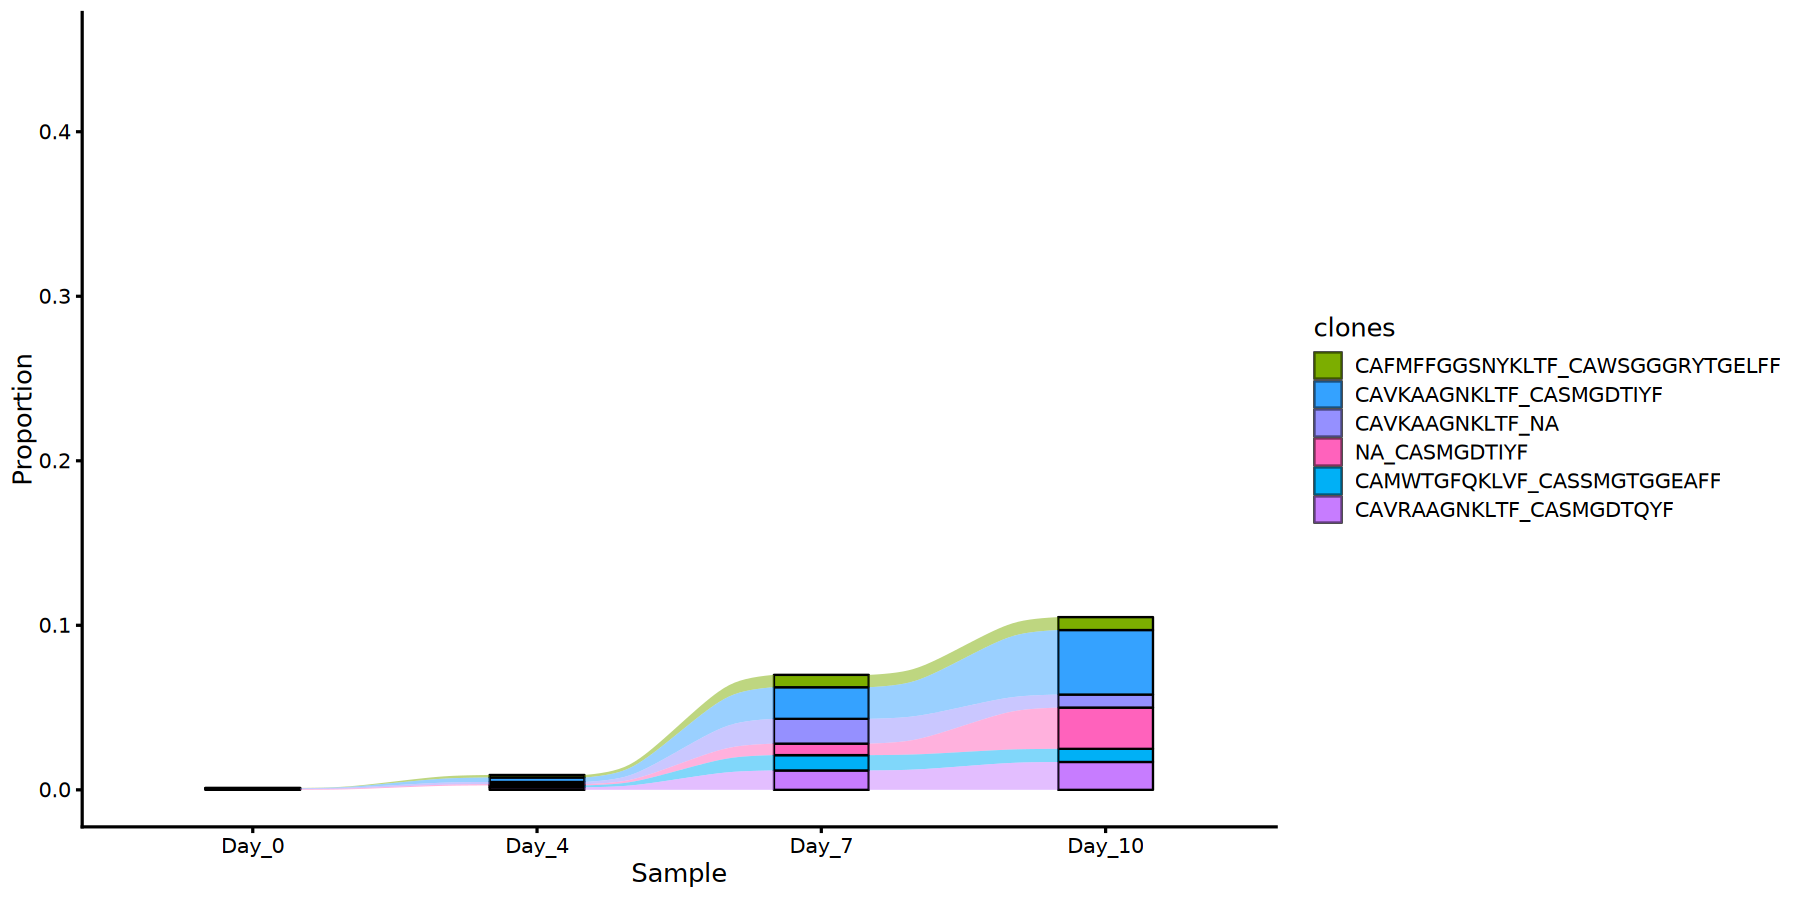

In [17]:
options(repr.plot.width = 15, repr.plot.height = 7.5)
so %>% 
    subset(Culture != 'IL7_IL15') %>%
    subset(Peptide != 'Pep_neg') %>%
    subset(Donor == 'BW2164') %>%
    clonalCompare(group.by = 'Day', 
              order.by = c('Day_0','Day_4','Day_7','Day_10'), 
              relabel.clones = F,
              clones = top_20_CTaa,
              cloneCall="aa", 
              graph = "alluvial") + 
    scale_fill_manual(values = c(
        filter(color_table, CTaa == 'CAFMFFGGSNYKLTF_CAWSGGGRYTGELFF')$colors,
        filter(color_table, CTaa == 'CAVKAAGNKLTF_CASMGDTIYF')$colors,
        filter(color_table, CTaa == 'CAVKAAGNKLTF_NA')$colors,
        filter(color_table, CTaa == 'NA_CASMGDTIYF')$colors,
        filter(color_table, CTaa == 'CAMWTGFQKLVF_CASSMGTGGEAFF')$colors,
        filter(color_table, CTaa == 'CAVRAAGNKLTF_CASMGDTQYF')$colors
    )) +
    theme_classic(base_size = 15) + ylim(0,0.45)

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


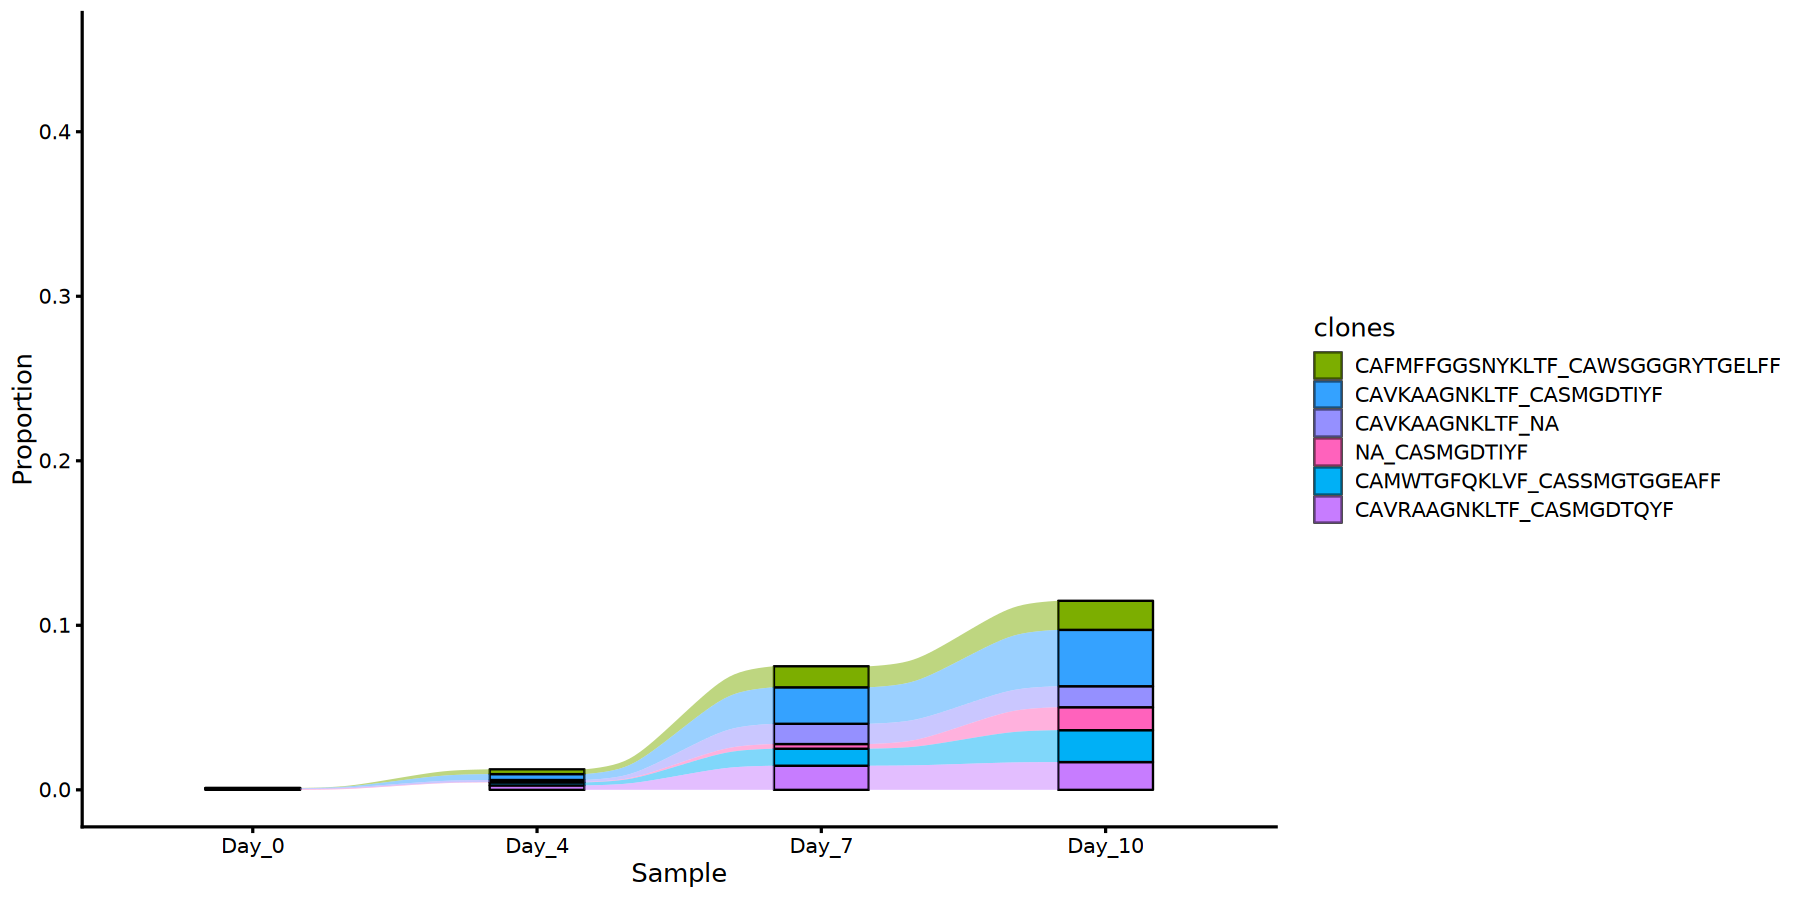

In [18]:
options(repr.plot.width = 15, repr.plot.height = 7.5)
so %>% 
    subset(Culture != 'IL4_IL7') %>%
    subset(Peptide != 'Pep_neg') %>%
    subset(Donor == 'BW2164') %>%
    clonalCompare(group.by = 'Day', 
              order.by = c('Day_0','Day_4','Day_7','Day_10'), 
              relabel.clones = F,
              clones = top_20_CTaa,
              cloneCall="aa", 
              graph = "alluvial") + 
    scale_fill_manual(values = c(
        filter(color_table, CTaa == 'CAFMFFGGSNYKLTF_CAWSGGGRYTGELFF')$colors,
        filter(color_table, CTaa == 'CAVKAAGNKLTF_CASMGDTIYF')$colors,
        filter(color_table, CTaa == 'CAVKAAGNKLTF_NA')$colors,
        filter(color_table, CTaa == 'NA_CASMGDTIYF')$colors,
        filter(color_table, CTaa == 'CAMWTGFQKLVF_CASSMGTGGEAFF')$colors,
        filter(color_table, CTaa == 'CAVRAAGNKLTF_CASMGDTQYF')$colors
    )) +
    theme_classic(base_size = 15) + ylim(0,0.45)

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


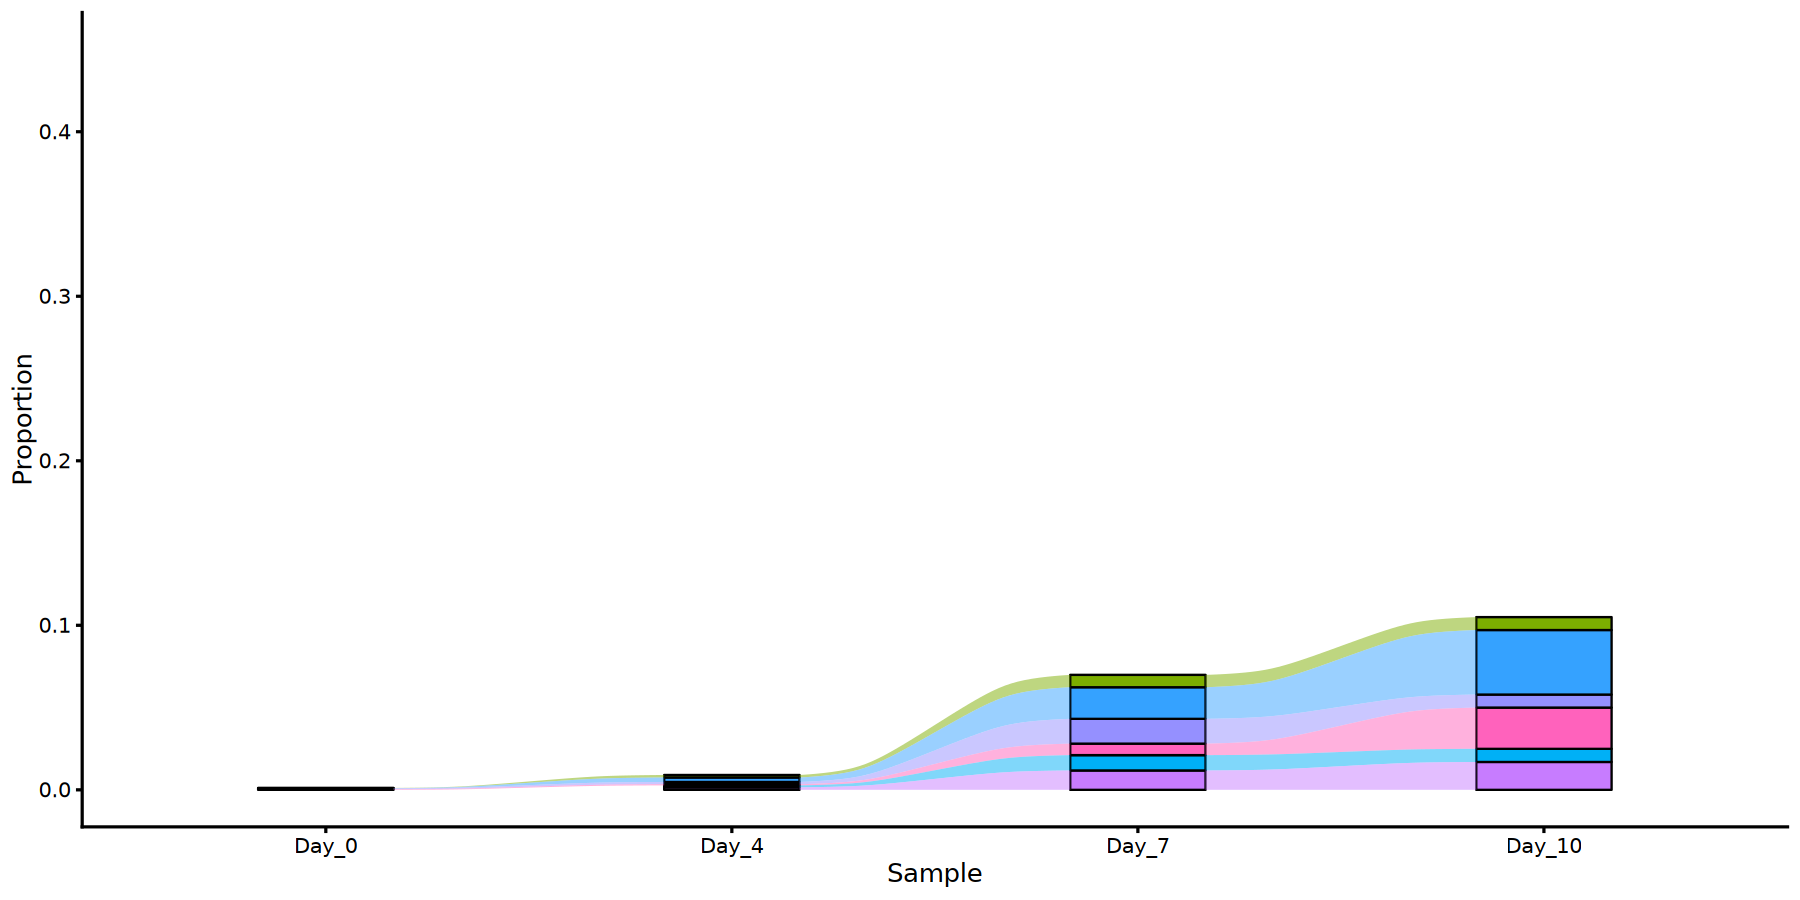

In [19]:
options(repr.plot.width = 15, repr.plot.height = 7.5)
bw2164_il4_plot <- so %>% 
    subset(Culture != 'IL7_IL15') %>%
    subset(Peptide != 'Pep_neg') %>%
    subset(Donor == 'BW2164') %>%
    clonalCompare(group.by = 'Day', 
              order.by = c('Day_0','Day_4','Day_7','Day_10'), 
              relabel.clones = F,
              clones = top_20_CTaa,
              cloneCall="aa", 
              graph = "alluvial") + 
    scale_fill_manual(values = c(
        filter(color_table, CTaa == 'CAFMFFGGSNYKLTF_CAWSGGGRYTGELFF')$colors,
        filter(color_table, CTaa == 'CAVKAAGNKLTF_CASMGDTIYF')$colors,
        filter(color_table, CTaa == 'CAVKAAGNKLTF_NA')$colors,
        filter(color_table, CTaa == 'NA_CASMGDTIYF')$colors,
        filter(color_table, CTaa == 'CAMWTGFQKLVF_CASSMGTGGEAFF')$colors,
        filter(color_table, CTaa == 'CAVRAAGNKLTF_CASMGDTQYF')$colors
    )) +
    theme_classic(base_size = 15) + ylim(0,0.45) + NoLegend()
bw2164_il4_plot

In [20]:
options(repr.plot.width = 15, repr.plot.height = 7.5)
bw2164_il15_plot <- so %>% 
    subset(Culture != 'IL4_IL7') %>%
    subset(Peptide != 'Pep_neg') %>%
    subset(Donor == 'BW2164') %>%
    clonalCompare(group.by = 'Day', 
              order.by = c('Day_0','Day_4','Day_7','Day_10'), 
              relabel.clones = F,
              clones = top_20_CTaa,
              cloneCall="aa", 
              graph = "alluvial") + 
    scale_fill_manual(values = c(
        filter(color_table, CTaa == 'CAFMFFGGSNYKLTF_CAWSGGGRYTGELFF')$colors,
        filter(color_table, CTaa == 'CAVKAAGNKLTF_CASMGDTIYF')$colors,
        filter(color_table, CTaa == 'CAVKAAGNKLTF_NA')$colors,
        filter(color_table, CTaa == 'NA_CASMGDTIYF')$colors,
        filter(color_table, CTaa == 'CAMWTGFQKLVF_CASSMGTGGEAFF')$colors,
        filter(color_table, CTaa == 'CAVRAAGNKLTF_CASMGDTQYF')$colors
    )) +
    theme_classic(base_size = 15) + ylim(0,0.45) + NoLegend()

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


## Donor 2

In [21]:
bw3446_il4_ctaa <- so@meta.data %>%
    filter(Culture != 'IL7_IL15') %>%
    filter(Peptide != 'Pep_neg') %>%
    filter(Donor == 'BW3446') %>%
    filter(CTaa %in% top_20_CTaa) %>%
    pull(CTaa) %>%
    unique() %>%
    sort()
bw3446_il4_ctaa

[1] "CADETGGGNKLTF_AGSYQLTF"          "CADETGGGNKLTF_CSARDVVQGDFRIGYTF"
[3] "CADETGGGNKLTF_NA"                "CAGKTSYDKVIF_CASSPGDEQFF"       
[5] "CAGKTSYDKVIF_NA"                 "CALSAPA_GNEKLTF"                
[7] "CGTEDHNNNDMRF_CASSESRYSEAFF"     "CVVVDWGNTPLVF_CASRPSLALQETQYF"  
[9] "NA_CASSPGDEQFF"

In [22]:
bw3446_il15_ctaa <- so@meta.data %>%
    filter(Culture != 'IL4_IL7') %>%
    filter(Peptide != 'Pep_neg') %>%
    filter(Donor == 'BW3446') %>%
    filter(CTaa %in% top_20_CTaa) %>%
    pull(CTaa) %>%
    unique() %>%
    sort()
bw3446_il15_ctaa

[1] "CADETGGGNKLTF_AGSYQLTF"          "CADETGGGNKLTF_CSARDVVQGDFRIGYTF"
[3] "CADETGGGNKLTF_NA"                "CAGKTSYDKVIF_CASSPGDEQFF"       
[5] "CAGKTSYDKVIF_NA"                 "CALSAPA_GNEKLTF"                
[7] "CGTEDHNNNDMRF_CASSESRYSEAFF"     "CVVVDWGNTPLVF_CASRPSLALQETQYF"  
[9] "NA_CASSPGDEQFF"

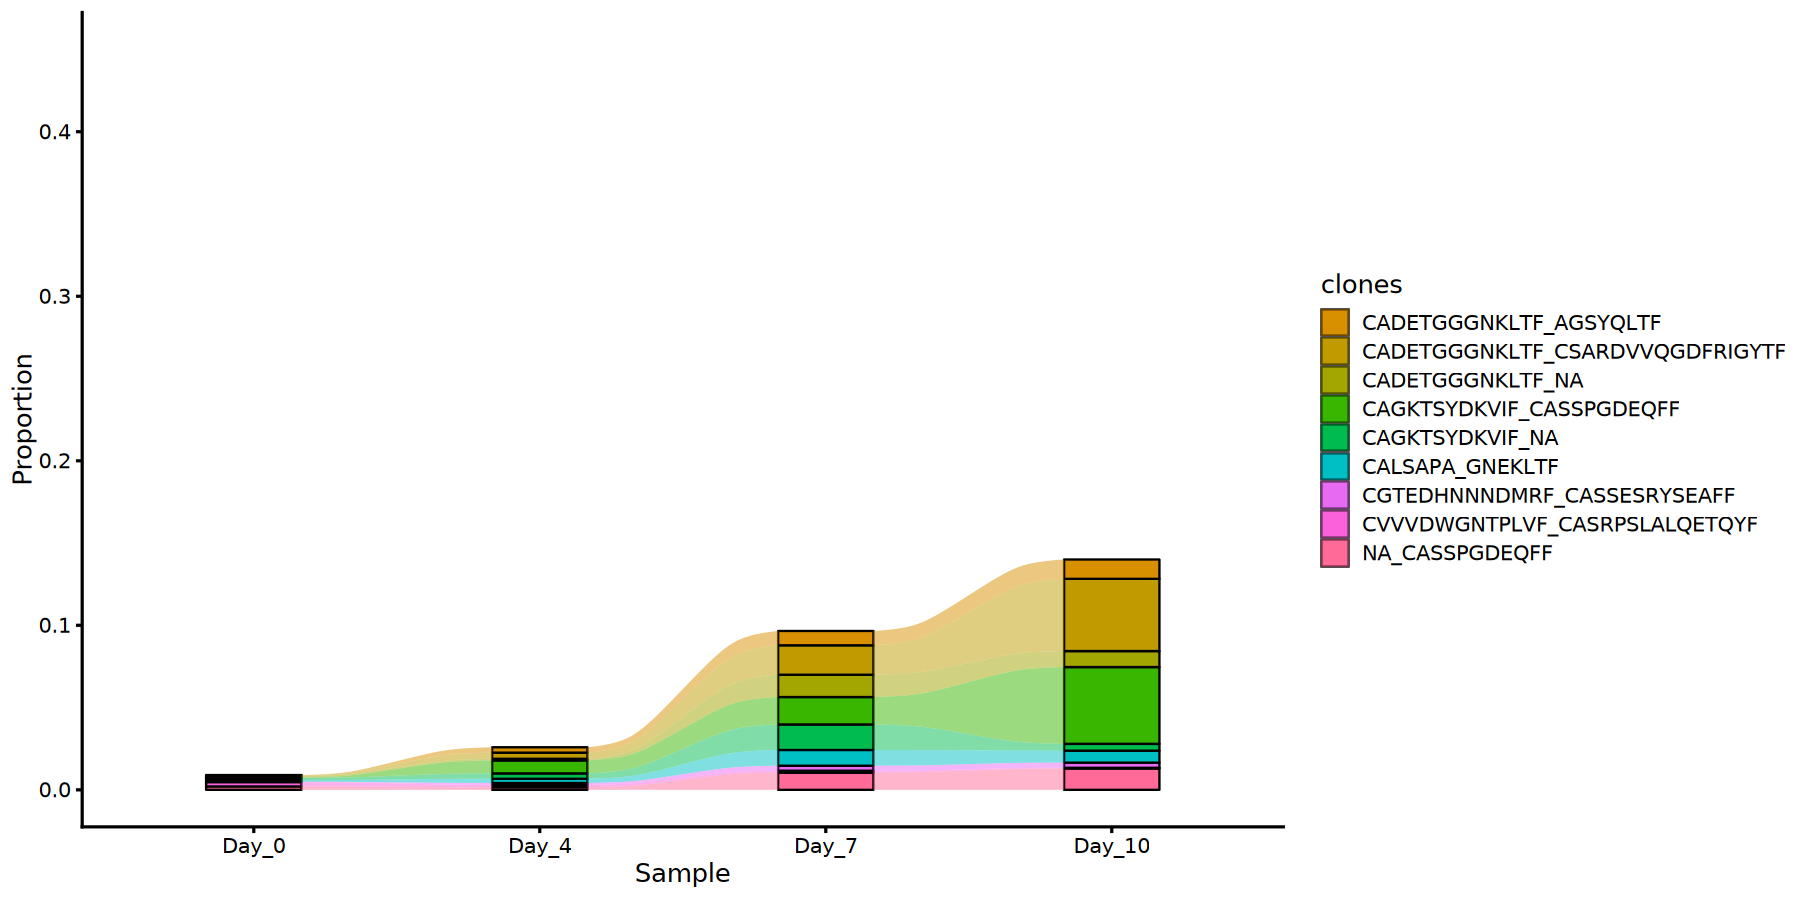

In [23]:
options(repr.plot.width = 15, repr.plot.height = 7.5)
so %>% 
    subset(Culture != 'IL7_IL15') %>%
    subset(Peptide != 'Pep_neg') %>%
    subset(Donor == 'BW3446') %>%
    clonalCompare(group.by = 'Day', 
              order.by = c('Day_0','Day_4','Day_7','Day_10'), 
              relabel.clones = F,
              clones = top_20_CTaa,
              cloneCall="aa", 
              graph = "alluvial") + 
    scale_fill_manual(values = c(
        filter(color_table, CTaa == 'CADETGGGNKLTF_AGSYQLTF')$colors,
        filter(color_table, CTaa == 'CADETGGGNKLTF_CSARDVVQGDFRIGYTF')$colors,
        filter(color_table, CTaa == 'CADETGGGNKLTF_NA')$colors,
        filter(color_table, CTaa == 'CAGKTSYDKVIF_CASSPGDEQFF')$colors,
        filter(color_table, CTaa == 'CAGKTSYDKVIF_NA')$colors,
        filter(color_table, CTaa == 'CALSAPA_GNEKLTF')$colors,
        filter(color_table, CTaa == 'CGTEDHNNNDMRF_CASSESRYSEAFF')$colors,
        filter(color_table, CTaa == 'CVVVDWGNTPLVF_CASRPSLALQETQYF')$colors,
        filter(color_table, CTaa == 'NA_CASSPGDEQFF')$colors
    )) +
    theme_classic(base_size = 15) + ylim(0,0.45)

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


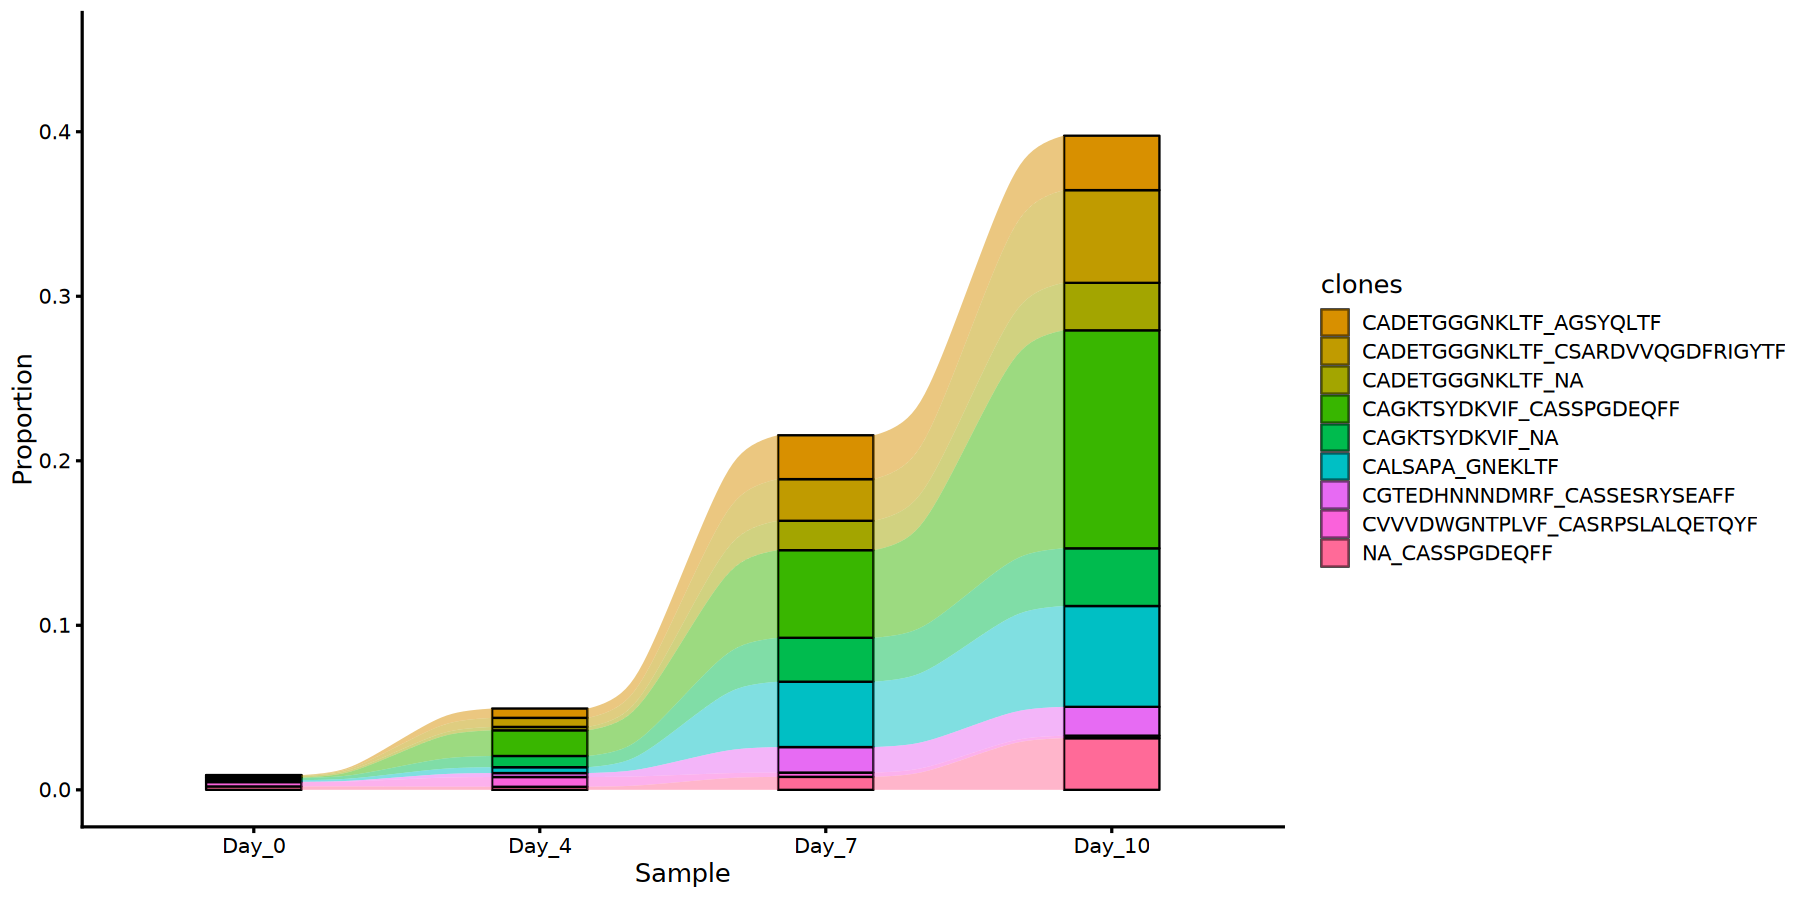

In [24]:
options(repr.plot.width = 15, repr.plot.height = 7.5)
so %>% 
    subset(Culture != 'IL4_IL7') %>%
    subset(Peptide != 'Pep_neg') %>%
    subset(Donor == 'BW3446') %>%
    clonalCompare(group.by = 'Day', 
              order.by = c('Day_0','Day_4','Day_7','Day_10'), 
              relabel.clones = F,
              clones = top_20_CTaa,
              cloneCall="aa", 
              graph = "alluvial") + 
    scale_fill_manual(values = c(
        filter(color_table, CTaa == 'CADETGGGNKLTF_AGSYQLTF')$colors,
        filter(color_table, CTaa == 'CADETGGGNKLTF_CSARDVVQGDFRIGYTF')$colors,
        filter(color_table, CTaa == 'CADETGGGNKLTF_NA')$colors,
        filter(color_table, CTaa == 'CAGKTSYDKVIF_CASSPGDEQFF')$colors,
        filter(color_table, CTaa == 'CAGKTSYDKVIF_NA')$colors,
        filter(color_table, CTaa == 'CALSAPA_GNEKLTF')$colors,
        filter(color_table, CTaa == 'CGTEDHNNNDMRF_CASSESRYSEAFF')$colors,
        filter(color_table, CTaa == 'CVVVDWGNTPLVF_CASRPSLALQETQYF')$colors,
        filter(color_table, CTaa == 'NA_CASSPGDEQFF')$colors
    )) +
    theme_classic(base_size = 15) + ylim(0,0.45)

In [25]:
options(repr.plot.width = 15, repr.plot.height = 7.5)
bw3446_il4_plot <- so %>% 
    subset(Culture != 'IL7_IL15') %>%
    subset(Peptide != 'Pep_neg') %>%
    subset(Donor == 'BW3446') %>%
    clonalCompare(group.by = 'Day', 
              order.by = c('Day_0','Day_4','Day_7','Day_10'), 
              relabel.clones = F,
              clones = top_20_CTaa,
              cloneCall="aa", 
              graph = "alluvial") + 
    scale_fill_manual(values = c(
        filter(color_table, CTaa == 'CADETGGGNKLTF_AGSYQLTF')$colors,
        filter(color_table, CTaa == 'CADETGGGNKLTF_CSARDVVQGDFRIGYTF')$colors,
        filter(color_table, CTaa == 'CADETGGGNKLTF_NA')$colors,
        filter(color_table, CTaa == 'CAGKTSYDKVIF_CASSPGDEQFF')$colors,
        filter(color_table, CTaa == 'CAGKTSYDKVIF_NA')$colors,
        filter(color_table, CTaa == 'CALSAPA_GNEKLTF')$colors,
        filter(color_table, CTaa == 'CGTEDHNNNDMRF_CASSESRYSEAFF')$colors,
        filter(color_table, CTaa == 'CVVVDWGNTPLVF_CASRPSLALQETQYF')$colors,
        filter(color_table, CTaa == 'NA_CASSPGDEQFF')$colors
    )) +
    theme_classic(base_size = 15) + ylim(0,0.45) + NoLegend()

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


In [26]:
options(repr.plot.width = 15, repr.plot.height = 7.5)
bw3446_il15_plot <- so %>% 
    subset(Culture != 'IL4_IL7') %>%
    subset(Peptide != 'Pep_neg') %>%
    subset(Donor == 'BW3446') %>%
    clonalCompare(group.by = 'Day', 
              order.by = c('Day_0','Day_4','Day_7','Day_10'), 
              relabel.clones = F,
              clones = top_20_CTaa,
              cloneCall="aa", 
              graph = "alluvial") + 
    scale_fill_manual(values = c(
        filter(color_table, CTaa == 'CADETGGGNKLTF_AGSYQLTF')$colors,
        filter(color_table, CTaa == 'CADETGGGNKLTF_CSARDVVQGDFRIGYTF')$colors,
        filter(color_table, CTaa == 'CADETGGGNKLTF_NA')$colors,
        filter(color_table, CTaa == 'CAGKTSYDKVIF_CASSPGDEQFF')$colors,
        filter(color_table, CTaa == 'CAGKTSYDKVIF_NA')$colors,
        filter(color_table, CTaa == 'CALSAPA_GNEKLTF')$colors,
        filter(color_table, CTaa == 'CGTEDHNNNDMRF_CASSESRYSEAFF')$colors,
        filter(color_table, CTaa == 'CVVVDWGNTPLVF_CASRPSLALQETQYF')$colors,
        filter(color_table, CTaa == 'NA_CASSPGDEQFF')$colors
    )) +
    theme_classic(base_size = 15) + ylim(0,0.45) + NoLegend()

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


## Donor 3

In [27]:
KT08836_il4_ctaa <- so@meta.data %>%
    filter(Culture != 'IL7_IL15') %>%
    filter(Peptide != 'Pep_neg') %>%
    filter(Donor == 'KT08836') %>%
    filter(CTaa %in% top_20_CTaa) %>%
    pull(CTaa) %>%
    unique() %>%
    sort()
KT08836_il4_ctaa

[1] "CAASADNAGNMLTF_CARDPPGLHYNEQFF"     "CAASADNAGNMLTF_CASSLPSALEQFF"      
[3] "CAGKTSYDKVIF_NA"                    "CAGVGSTSGTYKYIF_CASSEANLLAVYNNEQFF"
[5] "CALRGMNRDDKIIF_CASSISAQPQHF"        "CAMRDHV_NDYKLSF"                   
[7] "CAVKAAGNKLTF_NA"

In [28]:
KT08836_il15_ctaa <- so@meta.data %>%
    filter(Culture != 'IL4_IL7') %>%
    filter(Peptide != 'Pep_neg') %>%
    filter(Donor == 'KT08836') %>%
    filter(CTaa %in% top_20_CTaa) %>%
    pull(CTaa) %>%
    unique() %>%
    sort()
KT08836_il15_ctaa

[1] "CAASADNAGNMLTF_CARDPPGLHYNEQFF"     "CAASADNAGNMLTF_CASSLPSALEQFF"      
[3] "CAGVGSTSGTYKYIF_CASSEANLLAVYNNEQFF" "CALRGMNRDDKIIF_CASSISAQPQHF"       
[5] "CAMRDHV_NDYKLSF"                    "CAVKAAGNKLTF_NA"

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


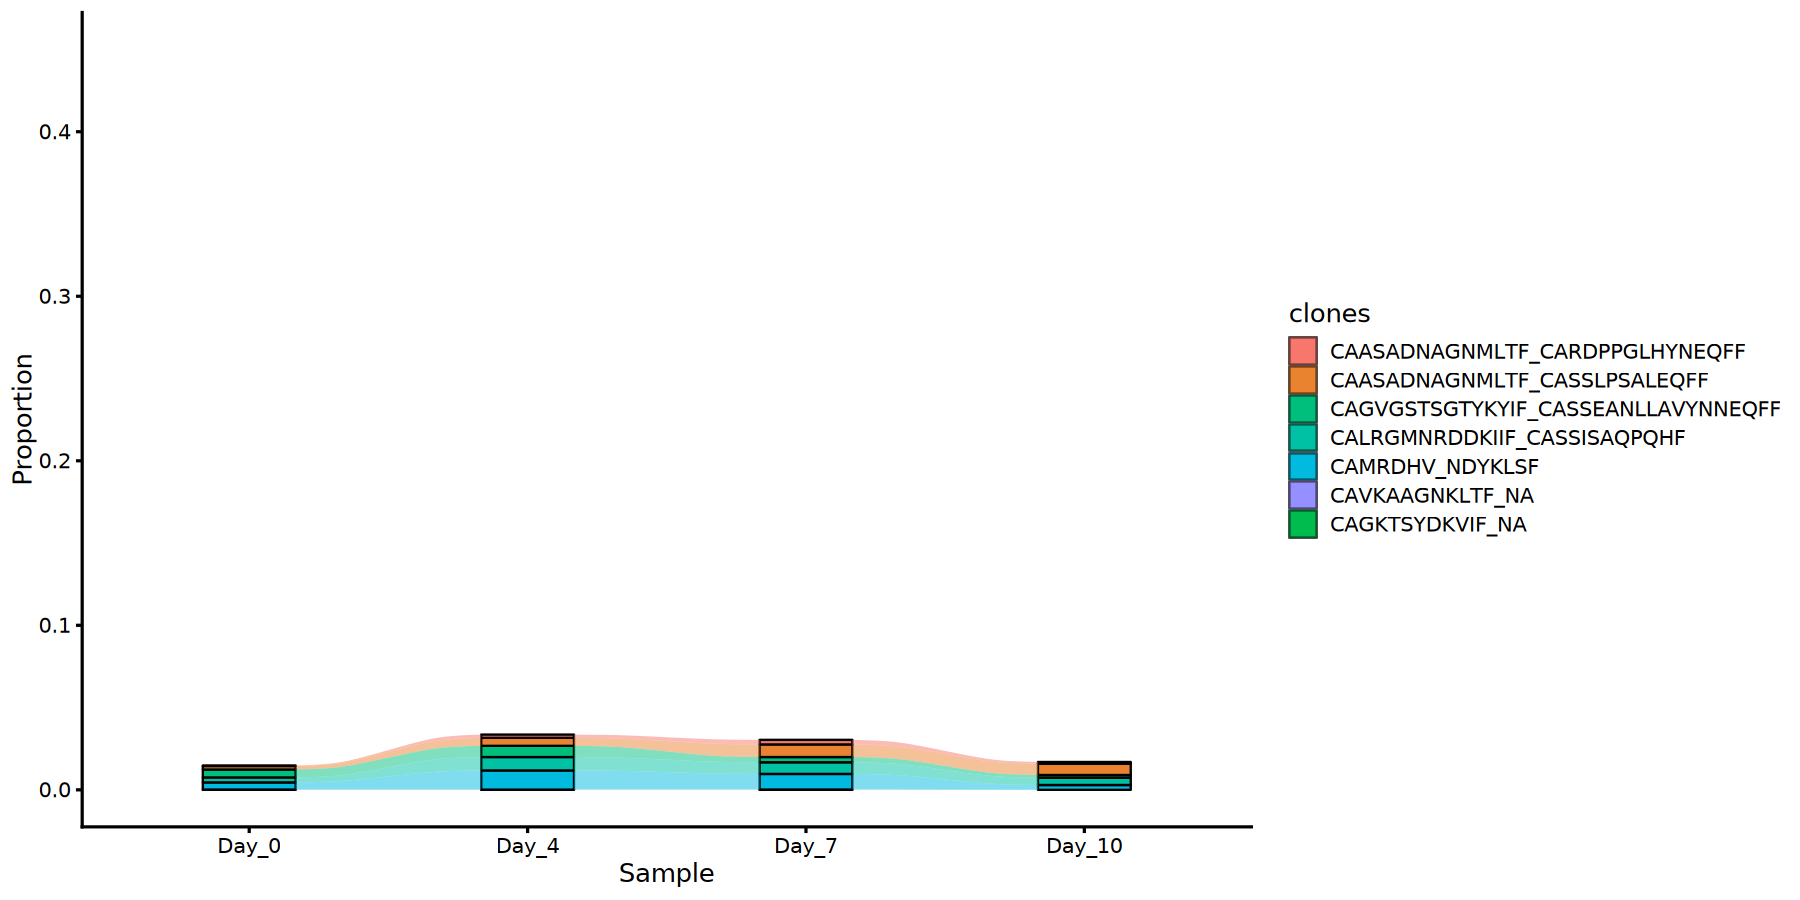

In [29]:
options(repr.plot.width = 15, repr.plot.height = 7.5)
so %>% 
    subset(Culture != 'IL7_IL15') %>%
    subset(Peptide != 'Pep_neg') %>%
    subset(Donor == 'KT08836') %>%
    clonalCompare(group.by = 'Day', 
              order.by = c('Day_0','Day_4','Day_7','Day_10'), 
              relabel.clones = F,
              clones = top_20_CTaa,
              cloneCall="aa", 
              graph = "alluvial") + 
    scale_fill_manual(values = c(
        filter(color_table, CTaa == 'CAASADNAGNMLTF_CARDPPGLHYNEQFF')$colors,
        filter(color_table, CTaa == 'CAASADNAGNMLTF_CASSLPSALEQFF')$colors,
        filter(color_table, CTaa == 'CAGVGSTSGTYKYIF_CASSEANLLAVYNNEQFF')$colors,
        filter(color_table, CTaa == 'CALRGMNRDDKIIF_CASSISAQPQHF')$colors,
        filter(color_table, CTaa == 'CAMRDHV_NDYKLSF')$colors,
        filter(color_table, CTaa == 'CAVKAAGNKLTF_NA')$colors,
        filter(color_table, CTaa == 'CAGKTSYDKVIF_NA')$colors
    )) +
    theme_classic(base_size = 15) + ylim(0,0.45)

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


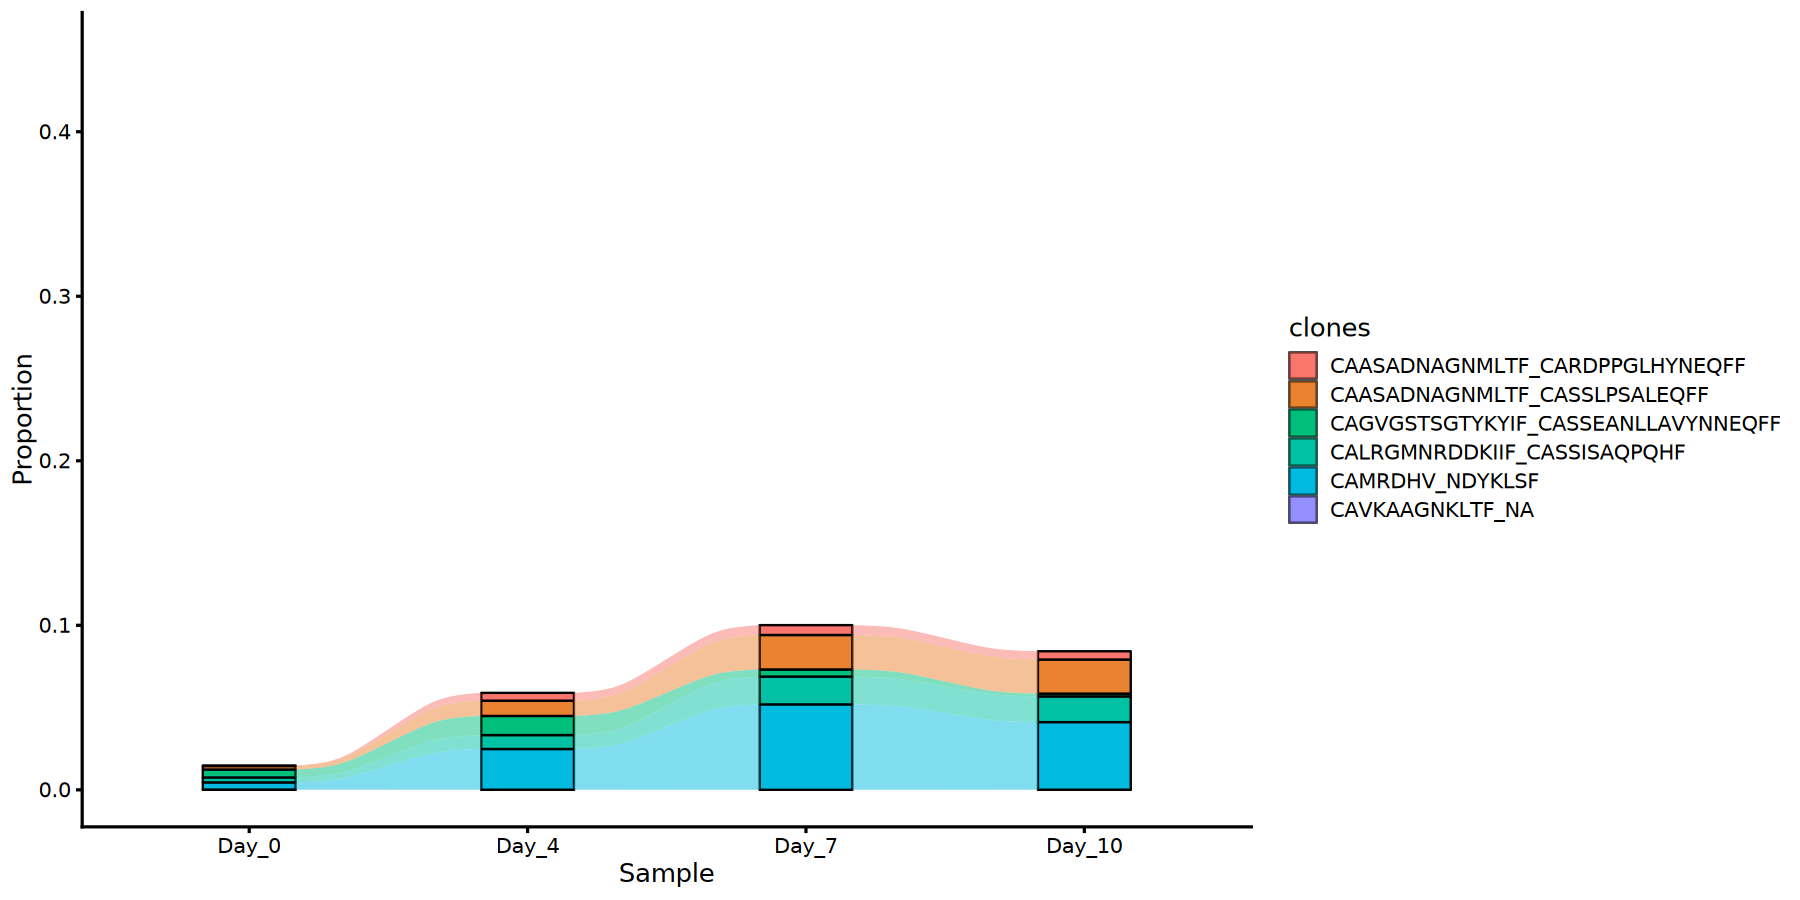

In [30]:
options(repr.plot.width = 15, repr.plot.height = 7.5)
so %>% 
    subset(Culture != 'IL4_IL7') %>%
    subset(Peptide != 'Pep_neg') %>%
    subset(Donor == 'KT08836') %>%
    clonalCompare(group.by = 'Day', 
              order.by = c('Day_0','Day_4','Day_7','Day_10'), 
              relabel.clones = F,
              clones = top_20_CTaa,
              cloneCall="aa", 
              graph = "alluvial") + 
    scale_fill_manual(values = c(
        filter(color_table, CTaa == 'CAASADNAGNMLTF_CARDPPGLHYNEQFF')$colors,
        filter(color_table, CTaa == 'CAASADNAGNMLTF_CASSLPSALEQFF')$colors,
        filter(color_table, CTaa == 'CAGVGSTSGTYKYIF_CASSEANLLAVYNNEQFF')$colors,
        filter(color_table, CTaa == 'CALRGMNRDDKIIF_CASSISAQPQHF')$colors,
        filter(color_table, CTaa == 'CAMRDHV_NDYKLSF')$colors,
        filter(color_table, CTaa == 'CAVKAAGNKLTF_NA')$colors
    )) +
    theme_classic(base_size = 15) + ylim(0,0.45)

In [31]:
options(repr.plot.width = 15, repr.plot.height = 7.5)
kt08836_il4_plot <- so %>% 
    subset(Culture != 'IL7_IL15') %>%
    subset(Peptide != 'Pep_neg') %>%
    subset(Donor == 'KT08836') %>%
    clonalCompare(group.by = 'Day', 
              order.by = c('Day_0','Day_4','Day_7','Day_10'), 
              relabel.clones = F,
              clones = top_20_CTaa,
              cloneCall="aa", 
              graph = "alluvial") + 
    scale_fill_manual(values = c(
        filter(color_table, CTaa == 'CAASADNAGNMLTF_CARDPPGLHYNEQFF')$colors,
        filter(color_table, CTaa == 'CAASADNAGNMLTF_CASSLPSALEQFF')$colors,
        filter(color_table, CTaa == 'CAGVGSTSGTYKYIF_CASSEANLLAVYNNEQFF')$colors,
        filter(color_table, CTaa == 'CALRGMNRDDKIIF_CASSISAQPQHF')$colors,
        filter(color_table, CTaa == 'CAMRDHV_NDYKLSF')$colors,
        filter(color_table, CTaa == 'CAVKAAGNKLTF_NA')$colors,
        filter(color_table, CTaa == 'CAGKTSYDKVIF_NA')$colors
    )) +
    theme_classic(base_size = 15) + ylim(0,0.45) + NoLegend()

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


In [32]:
options(repr.plot.width = 15, repr.plot.height = 7.5)
kt08836_il15_plot <- so %>% 
    subset(Culture != 'IL4_IL7') %>%
    subset(Peptide != 'Pep_neg') %>%
    subset(Donor == 'KT08836') %>%
    clonalCompare(group.by = 'Day', 
              order.by = c('Day_0','Day_4','Day_7','Day_10'), 
              relabel.clones = F,
              clones = top_20_CTaa,
              cloneCall="aa", 
              graph = "alluvial") + 
    scale_fill_manual(values = c(
        filter(color_table, CTaa == 'CAASADNAGNMLTF_CARDPPGLHYNEQFF')$colors,
        filter(color_table, CTaa == 'CAASADNAGNMLTF_CASSLPSALEQFF')$colors,
        filter(color_table, CTaa == 'CAGVGSTSGTYKYIF_CASSEANLLAVYNNEQFF')$colors,
        filter(color_table, CTaa == 'CALRGMNRDDKIIF_CASSISAQPQHF')$colors,
        filter(color_table, CTaa == 'CAMRDHV_NDYKLSF')$colors,
        filter(color_table, CTaa == 'CAVKAAGNKLTF_NA')$colors
    )) +
    theme_classic(base_size = 15) + ylim(0,0.45) + NoLegend()

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


## Combined for final plot

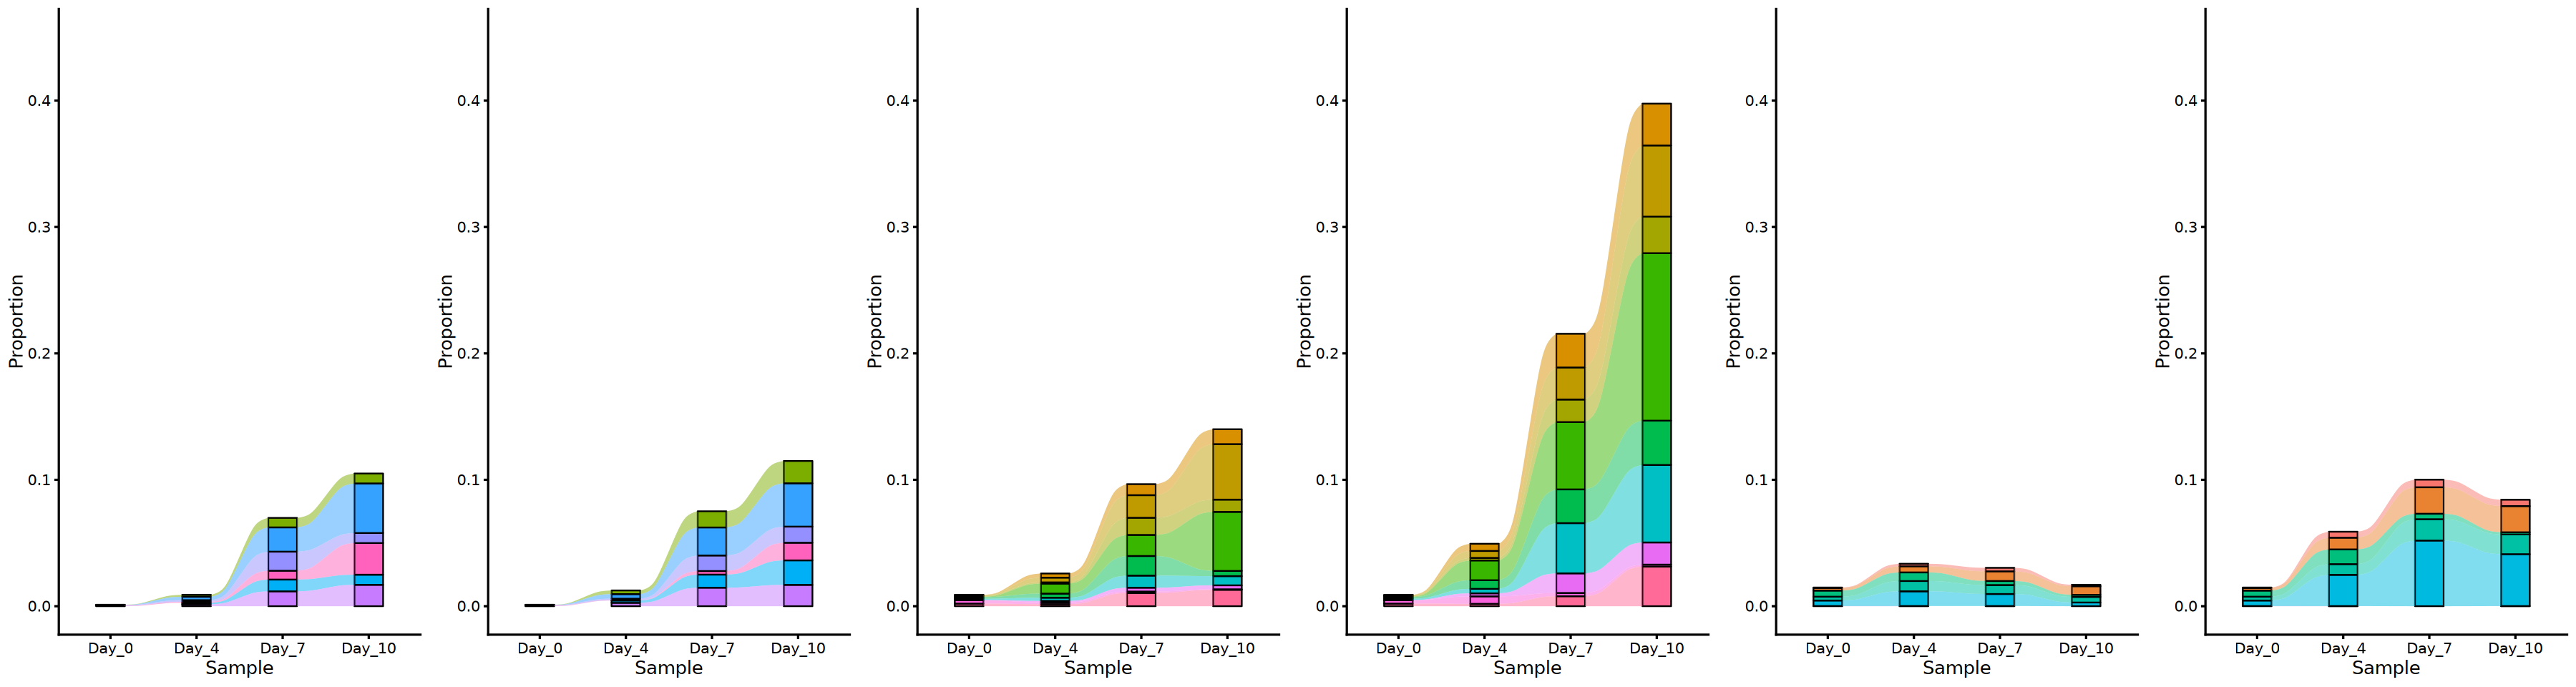

In [33]:
options(repr.plot.width = 30, repr.plot.height = 8)
cowplot::plot_grid(bw2164_il4_plot,bw2164_il15_plot,bw3446_il4_plot,bw3446_il15_plot,kt08836_il4_plot,kt08836_il15_plot, ncol=6)

In [34]:
# Open the PDF graphics device
pdf("plots/Fig2d_top_clones_per_donor.pdf", width = 30, height = 8) # You can specify width and height in inches

# Create your plot
cowplot::plot_grid(bw2164_il4_plot,bw2164_il15_plot,bw3446_il4_plot,bw3446_il15_plot,kt08836_il4_plot,kt08836_il15_plot, ncol=6)

# Close the graphics device to save the plot
dev.off()

pdf 
  2

In [35]:
# Open the PDF graphics device
pdf("plots/Fig2d_legend_reference.pdf", width = 15, height = 10) # You can specify width and height in inches

# Create your plot
p1

# Close the graphics device to save the plot
dev.off()

pdf 
  2